Análisis de desempeño comercial y rentabilidad de ventas multicanal (2021–2024)

In [1]:
# Importar librerias requeridas para el proyecto
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Obtener los datos del dataset
df = pd.read_csv('D:\\Descargas\\ventas_retail_2021_2024.csv')

In [3]:
# Revision del dataset cargado
df.head(5)

,fecha,producto,region,canal_venta,cantidad,descuento,categoria,precio_unitario,costo_unitario,cliente_id
0,2024-02-01,Teclado,Centro,Online,3.0,0.15,Accesorios,49.35,34.25,C023452
1,2024-12-30,Mouse,Centro,Tienda,3.0,0.00,Accesorios,39.18,26.75,C008690
2,2023-05-11,Mouse,Sur,Online,5.0,0.15,Accesorios,41.28,26.70,C029761
3,2024-07-18,Mouse,Norte,Online,3.0,0.05,Accesorios,37.56,24.13,C018979
4,2024-02-05,Monitor,Sur,Online,4.0,0.10,Electronica,310.72,220.08,C008116


In [4]:
# Identificar columnas
df.columns

Index(['fecha', 'producto', 'region', 'canal_venta', 'cantidad', 'descuento',
       'categoria', 'precio_unitario', 'costo_unitario', 'cliente_id'],
      dtype='str')

In [5]:
# Identificar formato de las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fecha            120000 non-null  str    
 1   producto         120000 non-null  str    
 2   region           120000 non-null  str    
 3   canal_venta      120000 non-null  str    
 4   cantidad         118800 non-null  float64
 5   descuento        120000 non-null  float64
 6   categoria        120000 non-null  str    
 7   precio_unitario  118800 non-null  float64
 8   costo_unitario   120000 non-null  float64
 9   cliente_id       120000 non-null  str    
dtypes: float64(4), str(6)
memory usage: 9.2 MB


In [6]:
# Obtener metricas estadisticas
df.describe()

,cantidad,descuento,precio_unitario,costo_unitario
count,118800.000000,120000.000000,118800.000000,120000.000000
mean,2.998796,0.075255,428.092164,288.905063
std,1.414603,0.055992,407.977312,276.486286
min,1.000000,0.000000,36.000000,21.630000
25%,2.000000,0.050000,52.530000,35.830000
50%,3.000000,0.100000,300.775000,202.350000
75%,4.000000,0.150000,761.940000,506.322500
max,5.000000,0.150000,1319.990000,987.610000


In [7]:
df.isna().sum()

fecha                 0
producto              0
region                0
canal_venta           0
cantidad           1200
descuento             0
categoria             0
precio_unitario    1200
costo_unitario        0
cliente_id            0
dtype: int64

Nos encontramos con un dataset muy completo, el cual nos describe detalladamente las ventas realizadas, en donde se pueden apreciar parametros como, fecha de venta, producto, region donde se realizo la venta, canal de venta, cantidad, descuento, categoria, precio unitario, costo unitario y el cliente que realizo la compra. Como observacion inicial, lo primero que observo es que se le debe dar formato a la columna fecha y la falta de 1200 datos en las columnas de cantidad y de precio unitario, lo cual complementaré basandome en los requisitos que tengan para el proyecto. Me podria indicar que desea obtener de esta informacion?

In [8]:
# Dar formato datetime a la columna fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

In [9]:
# Crear columnas de mes y año
df['mes'] = df['fecha'].dt.month
df['año'] = df['fecha'].dt.year

In [10]:
# Corroborar los cambios
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   fecha            120000 non-null  datetime64[us]
 1   producto         120000 non-null  str           
 2   region           120000 non-null  str           
 3   canal_venta      120000 non-null  str           
 4   cantidad         118800 non-null  float64       
 5   descuento        120000 non-null  float64       
 6   categoria        120000 non-null  str           
 7   precio_unitario  118800 non-null  float64       
 8   costo_unitario   120000 non-null  float64       
 9   cliente_id       120000 non-null  str           
 10  mes              120000 non-null  int32         
 11  año              120000 non-null  int32         
dtypes: datetime64[us](1), float64(4), int32(2), str(5)
memory usage: 10.1 MB


In [11]:
# Veryficar valores faltantes
df[df.isna().any(axis=1)]

,fecha,producto,region,canal_venta,cantidad,descuento,categoria,precio_unitario,costo_unitario,cliente_id,mes,año
111,2021-10-16,Smartphone,Norte,Tienda,5.0,0.15,Electronica,NaN,555.77,C029328,10,2021
278,2024-12-14,Smartphone,Sur,Online,NaN,0.15,Electronica,749.73,488.62,C012917,12,2024
286,2021-06-02,Audifonos,Norte,Online,4.0,0.15,Accesorios,NaN,64.24,C022157,6,2021
389,2022-02-04,Audifonos,Centro,Tienda,5.0,0.05,Accesorios,NaN,79.44,C017650,2,2022
396,2023-04-14,Monitor,Centro,Tienda,NaN,0.15,Electronica,281.28,173.44,C004658,4,2023
...,...,...,...,...,...,...,...,...,...,...,...,...
119814,2024-02-27,Smartphone,Norte,Tienda,NaN,0.05,Electronica,817.78,570.27,C024914,2,2024
119865,2023-10-04,Teclado,Sur,Online,1.0,0.05,Accesorios,NaN,38.59,C019786,10,2023
119880,2022-06-04,Monitor,Sur,Online,NaN,0.05,Electronica,315.45,198.74,C002676,6,2022
119934,2023-04-07,Tablet,Norte,Tienda,NaN,0.10,Electronica,466.31,288.23,C009015,4,2023


In [12]:
# Completar los valores faltantes en el dataset
df['precio_unitario'] = df['precio_unitario'].fillna(df.groupby('producto')['precio_unitario'].transform('mean'))
df['cantidad'] = df['cantidad'].fillna(df.groupby('producto')['cantidad'].transform('median'))

In [13]:
df.isna().sum()

fecha              0
producto           0
region             0
canal_venta        0
cantidad           0
descuento          0
categoria          0
precio_unitario    0
costo_unitario     0
cliente_id         0
mes                0
año                0
dtype: int64

In [14]:
# Calcular los ingresos
df['ingresos'] = df['precio_unitario'] * df['cantidad'] * (1 - df['descuento'])

In [15]:
# Calcular los costos totales
df['costo_total'] = df['costo_unitario'] * df['cantidad']

In [16]:
# Calcular utilidad
df['utilidad'] = df['ingresos'] - df['costo_total']

In [17]:
# Calcular margen de utilidad
df['margen_utilidad'] = df['utilidad'] / df['ingresos']

In [18]:
# Validacion de calculos
df[['ingresos','costo_total','utilidad','margen_utilidad']].describe()

,ingresos,costo_total,utilidad,margen_utilidad
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1189.534607,868.317807,321.216800,0.267390
std,1374.165447,1004.237475,394.619908,0.065015
min,30.625500,21.710000,2.280566,0.037957
25%,173.773500,126.750000,44.295500,0.221846
50%,560.323500,409.540000,151.355000,0.270295
75%,1773.877000,1294.580000,457.543750,0.315758
max,6598.300000,4937.850000,2602.100000,0.454198


In [19]:
# Rentabilidad por producto
pd.options.display.float_format = '{:,.5f}'.format
df.groupby('producto')['margen_utilidad'].mean().sort_values(ascending=False)

producto
Smartphone   0.26821
Teclado      0.26767
Laptop       0.26744
Tablet       0.26731
Monitor      0.26723
Mouse        0.26709
Audifonos    0.26678
Name: margen_utilidad, dtype: float64

In [20]:
df.groupby('producto')['margen_utilidad'].median().sort_values(ascending=False)

producto
Smartphone   0.27149
Teclado      0.27118
Tablet       0.27034
Mouse        0.27011
Audifonos    0.27005
Laptop       0.26968
Monitor      0.26958
Name: margen_utilidad, dtype: float64

In [21]:
# Metricas para definicion final
resumen_producto = df.groupby('producto').agg(ingresos_totales=('ingresos','sum'),utilidad_total=('utilidad','sum'))
resumen_producto['margen_ponderado'] = resumen_producto['utilidad_total'] / resumen_producto['ingresos_totales']


In [22]:
resumen_producto.head()

,ingresos_totales,utilidad_total,margen_ponderado
producto,,,
Audifonos,"4,697,419.38179","1,266,315.40179",0.26958
Laptop,"57,009,540.17839","15,363,857.84839",0.26950
Monitor,"14,252,649.80913","3,841,927.94913",0.26956
Mouse,"1,887,690.15360","509,861.43360",0.27010
Smartphone,"38,726,431.46188","10,491,045.55188",0.27090


In [23]:
# Definir umbrales
umbral_ingresos = resumen_producto['ingresos_totales'].median()
umbral_margen = resumen_producto['margen_ponderado'].median()

In [24]:
# Clasificacion estrategica
def clasificar_producto(row):
    if row['ingresos_totales'] >= umbral_ingresos and row['margen_ponderado'] >= umbral_margen:
        return 'Estrella'
    elif row['ingresos_totales'] >= umbral_ingresos and row['margen_ponderado'] < umbral_margen:
        return 'Volumen'
    elif row['ingresos_totales'] < umbral_ingresos and row['margen_ponderado'] >= umbral_margen:
        return 'Nicho'
    else:
        return 'Riesgo'

resumen_producto['segmento'] = resumen_producto.apply(clasificar_producto, axis=1)

In [25]:
# validacion
resumen_producto['segmento']

producto
Audifonos       Riesgo
Laptop         Volumen
Monitor        Volumen
Mouse            Nicho
Smartphone    Estrella
Tablet        Estrella
Teclado          Nicho
Name: segmento, dtype: str

El análisis de segmentación revela que smartphones y tablets se posicionan como productos “Estrella”, combinando altos ingresos y márgenes sólidos. Por el contrario, los audífonos se clasifican como “Riesgo”, al presentar bajo impacto económico y rentabilidad reducida. Esta situación sugiere la necesidad de revisar su estructura de costos, estrategia de precios o desempeño comercial por canal antes de tomar decisiones operativas.

In [26]:
resumen_producto.head()

,ingresos_totales,utilidad_total,margen_ponderado,segmento
producto,,,,
Audifonos,"4,697,419.38179","1,266,315.40179",0.26958,Riesgo
Laptop,"57,009,540.17839","15,363,857.84839",0.26950,Volumen
Monitor,"14,252,649.80913","3,841,927.94913",0.26956,Volumen
Mouse,"1,887,690.15360","509,861.43360",0.27010,Nicho
Smartphone,"38,726,431.46188","10,491,045.55188",0.27090,Estrella


In [27]:
# Definir colores para graficas de segmentos
colores = {'Estrella':'green','Volumen':'orange','Nicho':'blue','Riesgo':'red'}

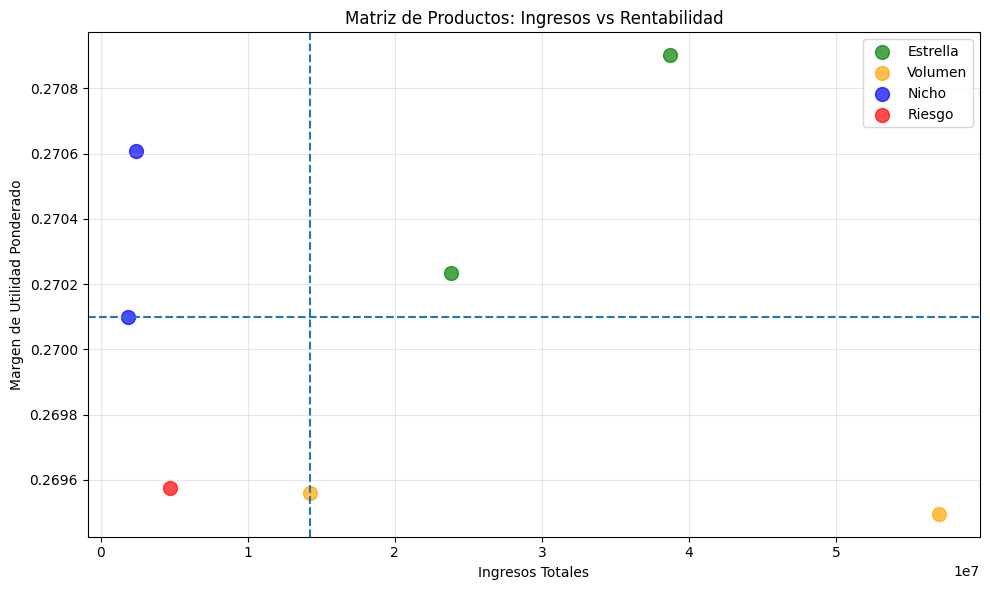

In [28]:
# Grafica scatter plot
plt.figure(figsize=(10,6))

for segmento , color in colores.items():
    data = resumen_producto[resumen_producto['segmento'] == segmento]
    plt.scatter(
        data['ingresos_totales'],
        data['margen_ponderado'],
        label = segmento,
        color = color,
        s=100,
        alpha=0.7
    )

plt.axvline(umbral_ingresos, linestyle='--')
plt.axhline(umbral_margen, linestyle='--')

plt.xlabel('Ingresos Totales')
plt.ylabel('Margen de Utilidad Ponderado')
plt.title('Matriz de Productos: Ingresos vs Rentabilidad')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()